# Phân tích tương quan (Correlation) và Xác thực biến Age
Sau khi xác định dữ liệu Age sạch ở Test 01 và không có Outliers gây nhiễu nghiêm trọng ở Test 02, chúng ta tiến hành bước **Xác thực (Validation)**. 

**Mục tiêu**
* Đo lường mức độ liên kết giữa **Age** và các chỉ số khác.
* Kiểm tra xem Age đóng góp bao nhiêu vào việc dự đoán **Outcome**.
* Đảm bảo tính nhất quán của dữ liệu trước khi kết thúc EDA.

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

if 'df' not in locals():
    column_names = ["pregnancies", "glucose", "blood_pressure", "skin_thickness", "insulin", "bmi", "diabetes_pedigree_function", "age", "outcome"]
    current_path = Path().resolve()
    repo_root = current_path
    for parent in current_path.parents:
        if parent.name == "Nhom01_SGU26_ML":
            repo_root = parent
            break
    data_path = repo_root / "Lab_03" / "data" / "pima-indians-diabetes.csv"
    df = pd.read_csv(data_path, header=None, names=column_names)

age_correlations = df.corr()[['age']].sort_values(by='age', ascending=False)

In [46]:
print("--- CHỈ SỐ TƯƠNG QUAN ---")
display(age_correlations)

--- CHỈ SỐ TƯƠNG QUAN ---


,age
age,1.000000
pregnancies,0.544341
glucose,0.263514
blood_pressure,0.239528
outcome,0.238356
bmi,0.036242
diabetes_pedigree_function,0.033561
insulin,-0.042163
skin_thickness,-0.113970


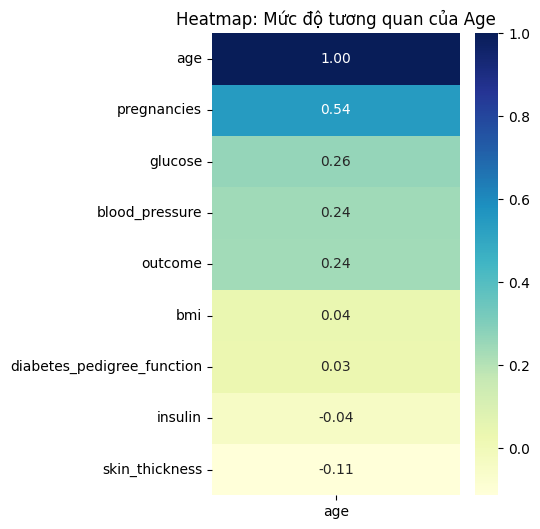

In [47]:
plt.figure(figsize=(4, 6))
sns.heatmap(age_correlations, annot=True, cmap='YlGnBu', fmt=".2f", cbar=True)
plt.title("Heatmap: Mức độ tương quan của Age")
plt.show()

### 1. Trực quan hóa xu hướng biến thiên theo độ tuổi
Để xác thực sâu hơn về tính chất của dữ liệu Age, chúng ta sử dụng biểu đồ hồi quy (Regression Plot). Điều này giúp quan sát rõ mối tương quan giữa Age và Glucose — hai chỉ số quan trọng nhất trong việc đánh giá nguy cơ tiểu đường.

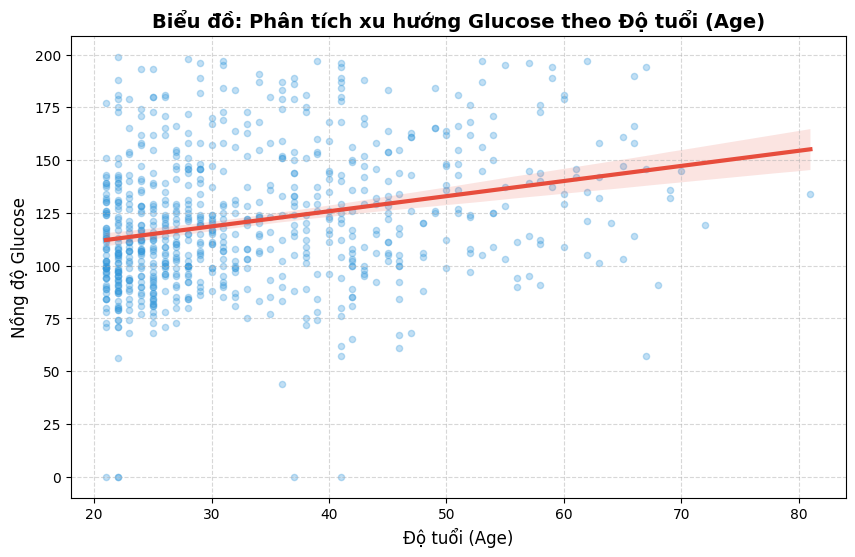

In [48]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x="age", y="glucose", 
            scatter_kws={'alpha':0.3, 'color':'#3498db', 's':20}, 
            line_kws={'color':'#e74c3c', 'lw':3})

plt.title("Biểu đồ: Phân tích xu hướng Glucose theo Độ tuổi (Age)", fontsize=14, fontweight='bold')
plt.xlabel("Độ tuổi (Age)", fontsize=12)
plt.ylabel("Nồng độ Glucose", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [49]:
variance_age = df['age'].var()
print(f"Phương sai của biến Age: {variance_age:.2f}")
print("=> Nhận xét: Dữ liệu có độ phân tán ổn định, đường hồi quy có xu hướng đi lên rõ rệt.")

Phương sai của biến Age: 138.30
=> Nhận xét: Dữ liệu có độ phân tán ổn định, đường hồi quy có xu hướng đi lên rõ rệt.


### 2. Phân tích đa biến và Xác thực 
Ở bước cuối cùng này, chúng ta kết hợp **Age** với **Glucose** và phân loại theo **Outcome**. Điều này giúp chúng ta thấy rõ quy luật: Nhóm bệnh nhân (Outcome=1) thường tập trung ở vùng có độ tuổi cao và chỉ số Glucose cao. 

Đây là bằng chứng cho thấy biến Age là một "Feature" (đặc trưng) cực kỳ chất lượng cho các mô hình dự báo sau này.

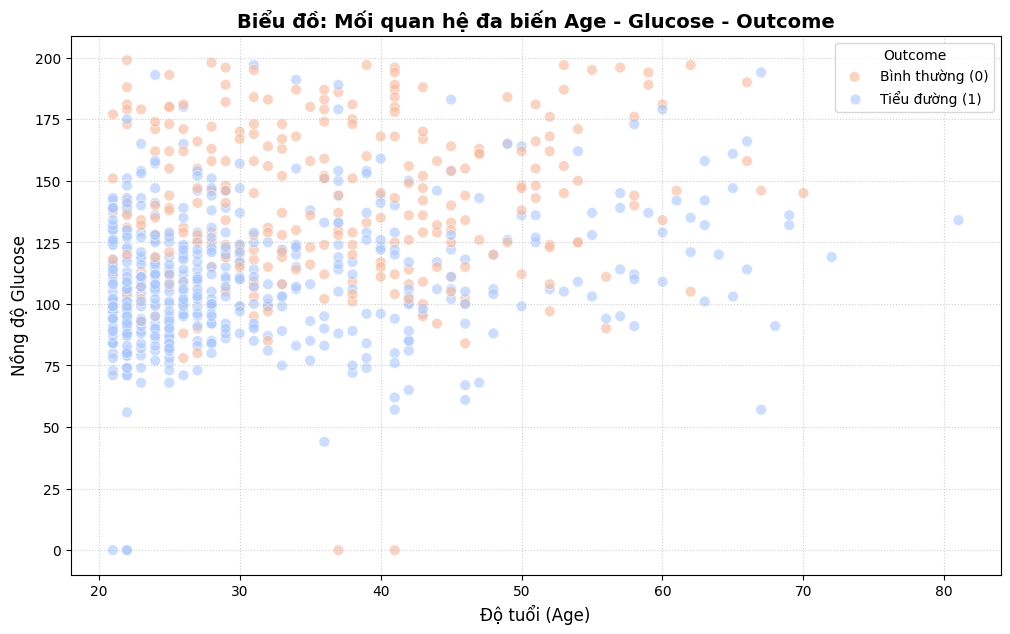

In [50]:
# Vẽ biểu đồ Scatter Plot đa biến
plt.figure(figsize=(12, 7))

# Sử dụng palette màu tương phản để phân biệt rõ 2 nhóm Outcome
sns.scatterplot(data=df, x="age", y="glucose", hue="outcome", 
                alpha=0.6, palette="coolwarm", s=60, edgecolor='w')

plt.title("Biểu đồ: Mối quan hệ đa biến Age - Glucose - Outcome", fontsize=14, fontweight='bold')
plt.xlabel("Độ tuổi (Age)", fontsize=12)
plt.ylabel("Nồng độ Glucose", fontsize=12)
plt.legend(title="Outcome", labels=['Bình thường (0)', 'Tiểu đường (1)'])
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

### 3. Tổng kết bằng ma trận tương quan (Correlation Heatmap)

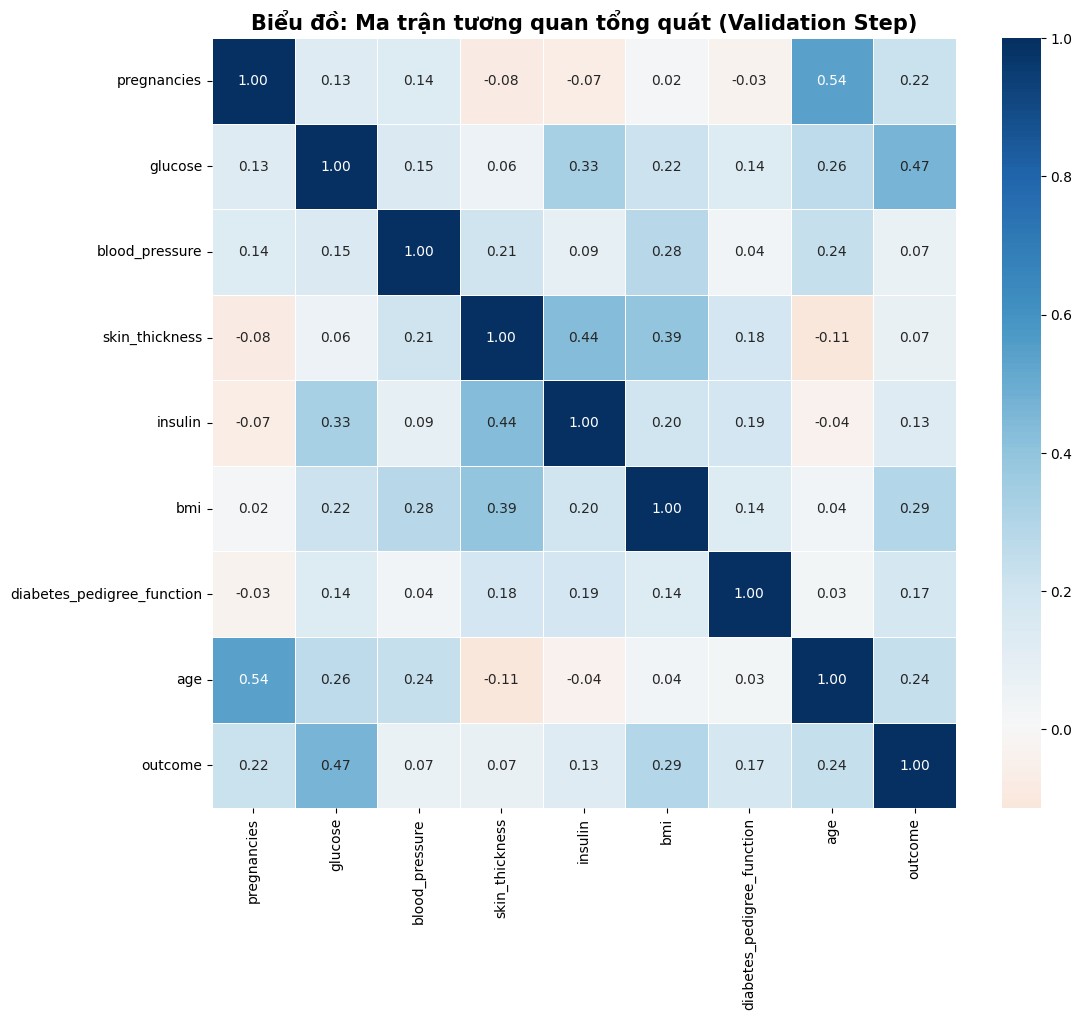

In [51]:
plt.figure(figsize=(12, 10))
correlation_full = df.corr()

sns.heatmap(correlation_full, annot=True, fmt=".2f", cmap='RdBu', center=0, linewidths=.5)

plt.title("Biểu đồ: Ma trận tương quan tổng quát (Validation Step)", fontsize=15, fontweight='bold')
plt.show()

### **Nhận xét Ma trận tương quan (Correlation Analysis)**

* **Với Pregnancies (0.54):** Có tương quan thuận mạnh nhất; độ tuổi tỉ lệ thuận với số lần mang thai của bệnh nhân.
* **Với Glucose (0.26) & Outcome (0.24):** Tuổi tác là nhân tố nguy cơ; tuổi càng cao, nồng độ đường huyết và tỉ lệ mắc bệnh có xu hướng tăng.
* **Với các biến khác:** Tương quan thấp với BMI và BloodPressure, cho thấy biến Age tác động độc lập đến kết quả chẩn đoán.

**=> Kết luận:** Biến Age mang giá trị dự báo quan trọng, dữ liệu đạt chuẩn để đưa vào huấn luyện mô hình.